In [1]:
# ─── Imports ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

In [2]:
# ─── Display Settings ──────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)


In [3]:
# ─── Plot Styling ───────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

In [5]:
df1 = pd.read_excel("C:\\Users\\DELL\\rfm-analysis\\data\\raw\\online_retail_II.xlsx", sheet_name = 'Year 2009-2010')
df2 = pd.read_excel("C:\\Users\\DELL\\rfm-analysis\\data\\raw\\online_retail_II.xlsx", sheet_name = 'Year 2010-2011')

df = pd.concat([df1,df2],ignore_index=True)
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.00,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.00,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.00,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.00,France


In [6]:
print(f"Total records in the data : {df.shape[0]:,}")
print(f"Total columns : {df.shape[1]}")
print(f"\nColumns: {df.columns.tolist()}")

Total records in the data : 1,067,371
Total columns : 8

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [7]:
# ─── Data Types & Memory Usage ─────────────────────────────
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

Memory usage: 249.05 MB


In [8]:
df.describe()


,Quantity,InvoiceDate,Price,Customer ID
count,1067371.00,1067371,1067371.00,824364.00
mean,9.94,2011-01-02 21:13:55.394029,4.65,15324.64
min,-80995.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-07-09 09:46:00,1.25,13975.00
50%,3.00,2010-12-07 15:28:00,2.10,15255.00
75%,10.00,2011-07-22 10:23:00,4.15,16797.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,172.71,NaN,123.55,1697.46


In [9]:
# ─── Missing Values Analysis ──────────────────────────────

missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing

,Missing Count,Missing %
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


In [10]:
missing = missing[missing['Missing Count'] >0 ].sort_values('Missing %',ascending =False)
missing

,Missing Count,Missing %
Customer ID,243007,22.77
Description,4382,0.41


In [11]:
# ─── Duplicate Check ───────────────────────────────────────

duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")
print(f"Duplicate %: {duplicates / len(df) * 100:.2f}%")



Duplicate rows: 34,335
Duplicate %: 3.22%


In [12]:
# Preview what duplicates look like
df[df.duplicated(keep=False)].head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.00,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.00,United Kingdom


In [13]:
# ─── Cancellation Analysis ─────────────────────────────────

cancellations = df[df['Invoice'].astype(str).str.startswith('C')]
print(f"Cancellation transactions: {cancellations.shape[0]:,}")
print(f"Cancellation %: {cancellations.shape[0] / len(df) * 100:.2f}%")
print(f"\nSample cancellations:")
cancellations.head(3)

Cancellation transactions: 19,494
Cancellation %: 1.83%

Sample cancellations:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia


In [14]:
# ─── Price Anomalies ───────────────────────────────────────

print("=== Negative Prices ===")
neg_price = df[df['Price'] < 0]
print(f"Count: {neg_price.shape[0]:,}")
print(neg_price.head(3))

print("\n=== Zero Prices ===")
zero_price = df[df['Price'] == 0]
print(f"Count: {zero_price.shape[0]:,}")
print(zero_price.head(3))

print("\n=== Negative Quantity (non-cancellation) ===")
neg_qty = df[(df['Quantity'] < 0) & (~df['Invoice'].astype(str).str.startswith('C'))]
print(f"Count: {neg_qty.shape[0]:,}")
print(neg_qty.head(3))

=== Negative Prices ===
Count: 5
        Invoice StockCode      Description  Quantity         InvoiceDate  \
179403  A506401         B  Adjust bad debt         1 2010-04-29 13:36:00   
276274  A516228         B  Adjust bad debt         1 2010-07-19 11:24:00   
403472  A528059         B  Adjust bad debt         1 2010-10-20 12:04:00   

           Price  Customer ID         Country  
179403 -53594.36          NaN  United Kingdom  
276274 -44031.79          NaN  United Kingdom  
403472 -38925.87          NaN  United Kingdom  

=== Zero Prices ===
Count: 6,202
    Invoice StockCode   Description  Quantity         InvoiceDate  Price  \
263  489464     21733  85123a mixed       -96 2009-12-01 10:52:00   0.00   
283  489463     71477         short      -240 2009-12-01 10:52:00   0.00   
284  489467    85123A   21733 mixed      -192 2009-12-01 10:53:00   0.00   

     Customer ID         Country  
263          NaN  United Kingdom  
283          NaN  United Kingdom  
284          NaN  United K

In [17]:
# ─── Country Distribution ───

country_stats = df.groupby('Country').agg(
    Transactions=('Invoice', 'nunique'),
    Customers=('Customer ID', 'nunique'),
    Revenue=('Price', 'sum')
).sort_values('Revenue', ascending=False)

country_stats

print(f"Total countries: {df['Country'].nunique()}")
print(f"\nTop 10 countries by transactions:")
print(country_stats.head(10))

Total countries: 43

Top 10 countries by transactions:
                Transactions  Customers    Revenue
Country                                           
United Kingdom         49108       5410 4453169.29
EIRE                     806          5  125305.45
Germany                 1095        107   67564.45
France                   746         95   67231.31
Norway                    53         13   41129.91
Singapore                 14          1   25481.40
Hong Kong                 21          0   20956.88
Spain                    188         41   20539.47
Portugal                 124         24   17125.84
Netherlands              250         23   15663.23


In [18]:
# ─── Time Range Validation ────
print(f"Date range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"Total days: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days}")

# Monthly transaction volume
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('YearMonth')['Invoice'].nunique()
print(f"\nMonthly transactions:")
print(monthly)

Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Total days: 738

Monthly transactions:
YearMonth
2009-12    2330
2010-01    1633
2010-02    1969
2010-03    2367
2010-04    1892
2010-05    2418
2010-06    2216
2010-07    2017
2010-08    1877
2010-09    2375
2010-10    2965
2010-11    3669
2010-12    2025
2011-01    1476
2011-02    1393
2011-03    1983
2011-04    1744
2011-05    2162
2011-06    2012
2011-07    1927
2011-08    1737
2011-09    2327
2011-10    2637
2011-11    3462
2011-12    1015
Freq: M, Name: Invoice, dtype: int64


In [19]:
# ─── Top Products & Customers ─────────

print("=== Top 10 Products by Revenue ===")
df['Revenue'] = df['Quantity'] * df['Price']
top_products = (df.groupby('Description')['Revenue']
                .sum()
                .sort_values(ascending=False)
                .head(10))
print(top_products)

print("\n=== Top 10 Customers by Revenue ===")
top_customers = (df.groupby('Customer ID')['Revenue']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))
print(top_customers)

=== Top 10 Products by Revenue ===
Description
REGENCY CAKESTAND 3 TIER              327813.65
DOTCOM POSTAGE                        322647.47
WHITE HANGING HEART T-LIGHT HOLDER    257533.90
JUMBO BAG RED RETROSPOT               148800.64
PARTY BUNTING                         147948.50
ASSORTED COLOUR BIRD ORNAMENT         131413.85
PAPER CHAIN KIT 50'S CHRISTMAS        121662.14
POSTAGE                               112341.00
CHILLI LIGHTS                          84854.16
ROTATING SILVER ANGELS T-LIGHT HLDR    73814.72
Name: Revenue, dtype: float64

=== Top 10 Customers by Revenue ===
Customer ID
18102.00   598215.22
14646.00   523342.07
14156.00   296564.69
14911.00   270248.53
17450.00   233579.39
13694.00   190825.52
17511.00   171885.98
12415.00   143269.29
16684.00   141502.25
15061.00   136391.48
Name: Revenue, dtype: float64


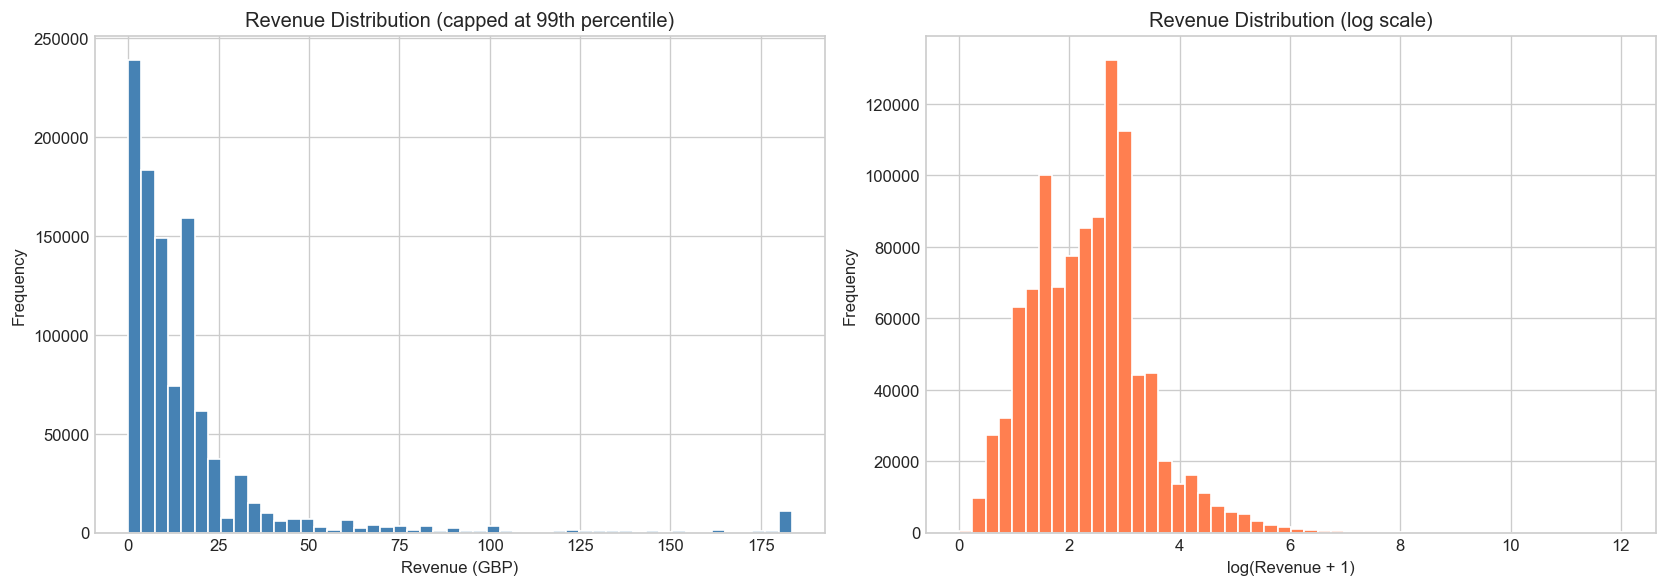

Plot saved to reports/


In [20]:
# ─── Revenue Distribution ─────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter valid revenue for plotting
rev = df[df['Revenue'] > 0]['Revenue']

# Raw distribution
axes[0].hist(rev.clip(upper=rev.quantile(0.99)), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Revenue Distribution (capped at 99th percentile)')
axes[0].set_xlabel('Revenue (GBP)')
axes[0].set_ylabel('Frequency')

# Log scale
axes[1].hist(np.log1p(rev), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Revenue Distribution (log scale)')
axes[1].set_xlabel('log(Revenue + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/revenue_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved to reports/")

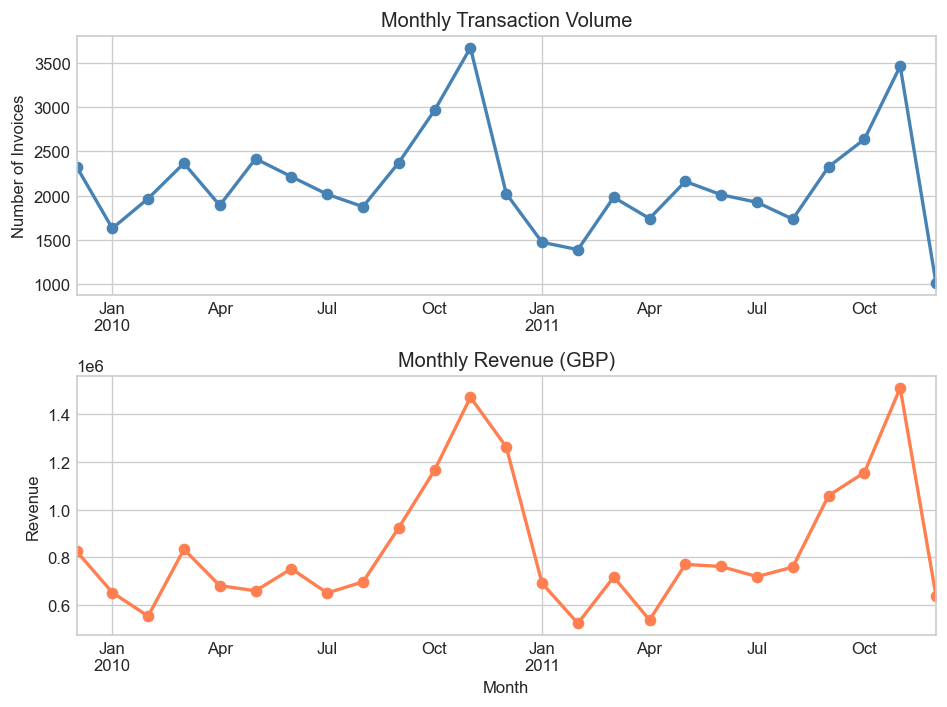

Plot saved to reports/


In [27]:
# ─── Transactions Over Time ────────────────────────────────
# Reveals seasonality, growth trends, and anomalies
# Seasonality is critical context for RFM — recency scores
# look different in December vs February

monthly_revenue = df[df['Revenue'] > 0].groupby('YearMonth')['Revenue'].sum()

fig, axes = plt.subplots(2, 1, figsize=(8, 6))

# Transaction count
monthly.plot(ax=axes[0], color='steelblue', marker='o', linewidth=2)
axes[0].set_title('Monthly Transaction Volume')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Invoices')

# Revenue
monthly_revenue.plot(ax=axes[1], color='coral', marker='o', linewidth=2)
axes[1].set_title('Monthly Revenue (GBP)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue')

plt.tight_layout()
plt.savefig('../reports/transactions_over_time.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved to reports/")

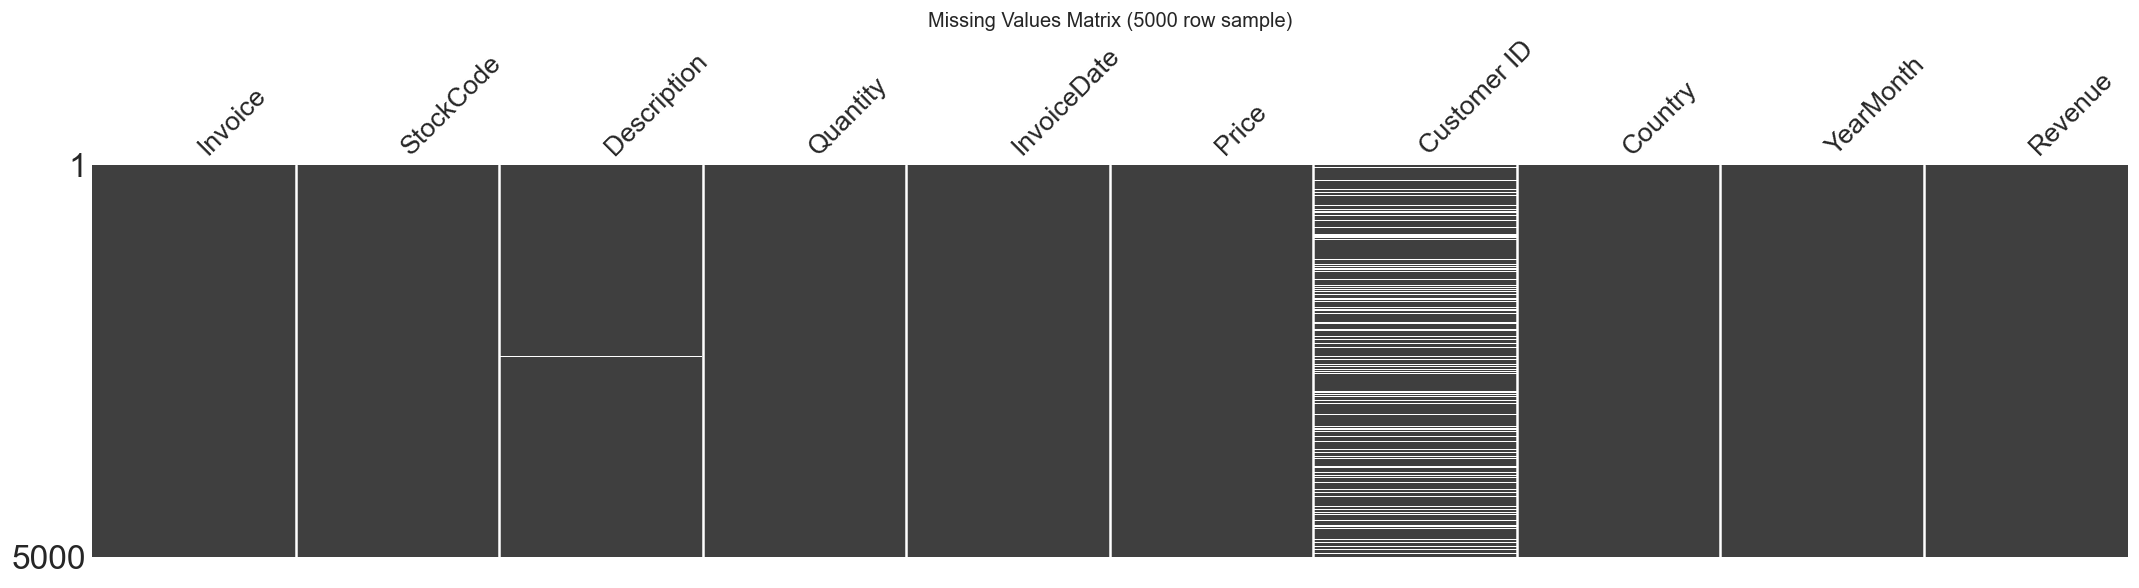

In [30]:
# ─── Missing Values Heatmap ──────────────
import missingno as msno

fig, ax = plt.subplots(figsize=(18, 5))
msno.matrix(df.sample(5000, random_state=42), ax=ax, sparkline=False)
ax.set_title('Missing Values Matrix (5000 row sample)')
plt.tight_layout()
plt.savefig('../reports/missing_values_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## EDA Summary — Key Findings

| Issue | Count | % of Total | Action |
|---|---|---|---|
| Missing Customer ID | 243,007 | 22.77% | Drop rows |
| Duplicate rows | 34,335 | 3.22% | Drop duplicates |
| Cancellations | 19,494 | 1.83% | Drop (Invoice starts with C) |
| Zero price rows | 6,202 | 0.58% | Drop rows |
| Negative quantities | 3,457 | 0.32% | Drop rows |
| Negative prices | 5 | 0.00% | Drop rows |

### Key Observations
- Dataset spans **Dec 2009 – Dec 2011** (2 years, ~1M transactions)
- **UK dominates** — majority of transactions are from United Kingdom
- Strong **seasonality** visible — peak in Nov-Dec each year
- After cleaning, estimated usable rows: ~**750,000+**
- **Customer ID** is the most critical field — rows without it are unusable for RFM